<a href="https://colab.research.google.com/github/Subhajit14mandal/chest-xray-pneumonia-detection-deep-learning/blob/main/Medical_Image_Classification_for_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downlode The Pneumonia Prediction Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# !mkdir ~/.kaggle/
# !cp "/content/drive/MyDrive/InLighnX Global/kaggle.json" ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p "/content/drive/MyDrive/InLighnX Global"
# !unzip "/content/drive/MyDrive/InLighnX Global/chest-xray-pneumonia.zip" -d "/content/drive/MyDrive/InLighnX Global"
# !rm "/content/drive/MyDrive/InLighnX Global/chest-xray-pneumonia.zip"

# Import Basic Libraries

In [ ]:
import tensorflow as tf

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, GlobalAveragePooling2D,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load Images

In [ ]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True,
                                 rotation_range=20,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)
train=train_datagen.flow_from_directory('/content/drive/MyDrive/InLighnX Global/chest_xray/train',
                                        target_size=(299,299),
                                        batch_size=32,
                                        class_mode='binary')
val=val_datagen.flow_from_directory('/content/drive/MyDrive/InLighnX Global/chest_xray/val',
                                    target_size=(299,299),
                                    batch_size=32,
                                    class_mode='binary',
                                    shuffle=False)
test=test_datagen.flow_from_directory('/content/drive/MyDrive/InLighnX Global/chest_xray/test',
                                      target_size=(299,299),
                                      batch_size=32,
                                      class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
print(f"Number of images in training set: {train.n}")
print(f"Number of images in validation set: {val.n}")
print(f"Number of images in test set: {test.n}")

Number of images in training set: 5216
Number of images in validation set: 16
Number of images in test set: 624


In [ ]:
train.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

# Handling Imbalanced

In [ ]:
import numpy as np
unique, counts = np.unique(train.labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int32(0): np.int64(1341), np.int32(1): np.int64(3875)}


In [ ]:
import matplotlib.pyplot as plt

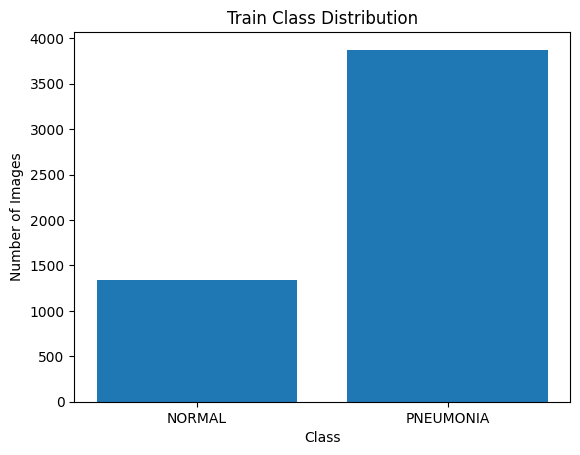

In [ ]:
class_names = list(train.class_indices.keys())
plt.bar(class_names, counts)
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Get class labels from the training generator
labels = train.classes

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convert class weights to a dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))

print("Class weights calculated successfully:", class_weights_dict)

Class weights calculated successfully: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


# Bulid The CNN Model

## Import `Xception` as Base

In [ ]:
from keras.applications import Xception

In [ ]:
conv_base=Xception(weights='imagenet',include_top=False,input_shape=(299,299,3))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model=Sequential()
model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3)) # Adjusted dropout rate
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3)) # Adjusted dropout rate
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2)) # Adjusted dropout rate
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2)) # Adjusted dropout rate
model.add(Dense(16,activation='relu'))
model.add(Dropout(0.1)) # Adjusted dropout rate
model.add(Dense(8,activation='relu'))
model.add(Dropout(0.05))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy',
                        tf.keras.metrics.AUC(name='auc'),
                        tf.keras.metrics.Recall(name='recall'),
                        tf.keras.metrics.Precision(name='precision'),])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,429,961 (81.75 MB)

 Trainable params: 21,375,433 (81.54 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
from keras.callbacks import EarlyStopping

## Callbacks

In [ ]:
early_stop=EarlyStopping(monitor='val_loss',
                         mode='min', # Changed from 'max' to 'min'
                         patience=8,
                         restore_best_weights=True,
                         verbose=1)

**EarlyStopping Callback**

`EarlyStopping` is a callback used to prevent overfitting and save training time. It monitors a specified metric (in this case, `val_loss`) and stops training if the metric stops improving for a certain number of epochs (`patience`).

*   `monitor='val_loss'`: The metric to be monitored. Here, it's the validation loss.
*   `mode='min'`: The training will stop when the monitored quantity has stopped decreasing (i.e., we are looking for the minimum validation loss).
*   `patience=8`: The number of epochs with no improvement after which training will be stopped.
*   `restore_best_weights=True`: Whether to restore model weights from the epoch with the best value of the monitored quantity. If True, the model will revert to its best state upon stopping.
*   `verbose=1`: Displays messages when the callback acts (e.g., when training stops early).

In [ ]:
from keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss',mode='max',
                                 factor=0.3, patience=4,
                                 verbose=1, min_lr=1e-6)
print("Learning rate scheduler 'ReduceLROnPlateau' defined.")

Learning rate scheduler 'ReduceLROnPlateau' defined.


**ReduceLROnPlateau Callback**

`ReduceLROnPlateau` is a callback that reduces the learning rate when a metric has stopped improving. This can help the model escape local minima and converge better.

*   `monitor='val_loss'`: The metric to be monitored. Here, it's also the validation loss.
*   `mode='max'`: The training will reduce the learning rate when the monitored quantity has stopped increasing (i.e., we are looking for the maximum of the monitored quantity). _Note: In the provided code, `mode` for `ReduceLROnPlateau` is set to 'max' while monitoring 'val_loss', which usually means looking for an increase in `val_loss`. This might be an oversight if the intention was to reduce LR when loss stops decreasing. For `val_loss`, `mode='min'` is typically used if you want to reduce LR when the loss stops getting smaller._
*   `factor=0.3`: Factor by which the learning rate will be reduced. new_lr = lr * factor.
*   `patience=4`: The number of epochs with no improvement after which the learning rate will be reduced.
*   `verbose=1`: Displays messages when the learning rate is reduced.
*   `min_lr=1e-6`: The lower bound on the learning rate.

## Train the Model

In [ ]:
model.fit(train,epochs=50,validation_data=test,
          callbacks=[lr_scheduler,early_stop],
          class_weight=class_weights_dict)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2196s 13s/step - accuracy: 0.7481 - auc: 0.8790 - loss: 0.5184 - precision: 0.9413 - recall: 0.6964 - val_accuracy: 0.6250 - val_auc: 0.5000 - val_loss: 107.9313 - val_precision: 0.6250 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9260 - auc: 0.9620 - loss: 0.2604 - precision: 0.9676 - recall: 0.9324 - val_accuracy: 0.6763 - val_auc: 0.8631 - val_loss: 1.9616 - val_precision: 0.9845 - val_recall: 0.4897 - learning_rate: 0.0010
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.9088 - auc: 0.9661 - loss: 0.2425 - precision: 0.9794 - recall: 0.8958 - val_accuracy: 0.5753 - val_auc: 0.7728 - val_loss: 4.7822 - val_precision: 1.0000 - val_recall: 0.3205 - learning_rate: 0.0010
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9408 - auc: 0.9843 - loss: 0.1566 - precision: 0.9878 - recall: 0.9324 - val_accuracy: 0.6394 - val_auc: 0.8629 - val_loss: 1.32

## Scoring

In [ ]:
test_accuracy=model.history.history['val_accuracy'][-1]
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9391025900840759


In [ ]:
train_accuracy=model.history.history['accuracy'][-1]
print(f"Train Accuracy: {train_accuracy}")

Train Accuracy: 0.9883052110671997


In [ ]:
loss, accuracy, auc, recall, precision = model.evaluate(val)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1092 - precision: 1.0000 - recall: 1.0000
Test Loss: 0.1092076450586319
Test Accuracy: 1.0


In [ ]:
predictions = model.predict(val)
true_labels = val.classes

print("Predictions generated successfully.")
print("True labels extracted successfully.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predictions generated successfully.
True labels extracted successfully.


### Visualize Misclassifications

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Define the class mapping as requested
class_mapping = {'NORMAL': 0, 'PNEUMONIA': 1}
idx_to_class = {v: k for k, v in class_mapping.items()}

# Ensure 'test' is available from previous steps; re-predict to be safe if 'val' was used before this cell.
# It seems 'test' was used previously for the initial definition, so we'll stick to 'test'.
predictions = model.predict(val)
true_labels = val.classes
predicted_classes = np.round(predictions).flatten()

# Find indices of incorrectly classified images
incorrect_indices = np.where(predicted_classes != true_labels)[0]

# Get the filenames of the incorrectly classified images
incorrect_filenames = [val.filenames[i] for i in incorrect_indices]

print(f"Found {len(incorrect_indices)} incorrectly classified images.")

# Display all incorrectly classified images
if len(incorrect_indices) > 0:
    # Calculate rows and columns for subplot grid
    cols = 5  # Number of columns
    rows = (len(incorrect_indices) + cols - 1) // cols # Calculate rows needed

    plt.figure(figsize=(3 * cols, 3 * rows)) # Adjust figure size dynamically

    for i, idx in enumerate(incorrect_indices):
        # Get the original image path
        original_image_path = test.directory + '/' + test.filenames[idx]

        # Load and display the image
        img = plt.imread(original_image_path)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"True: {idx_to_class[true_labels[idx]]}, Pred: {idx_to_class[int(predicted_classes[idx])]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No incorrectly classified images to display.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Found 0 incorrectly classified images.
No incorrectly classified images to display.


In [ ]:
print("\nEvaluating model on the test dataset...")
loss_test, accuracy_test, auc_test, recall_test, precision_test = model.evaluate(test)
print(f"Test Loss: {loss_test:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}")


Evaluating model on the test dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 408ms/step - accuracy: 0.9481 - auc: 0.9804 - loss: 0.1675 - precision: 0.9422 - recall: 0.9762
Test Loss: 0.2362
Test Accuracy: 0.9407


### Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step

Classification Report (Test Set):
               precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00         8
   PNEUMONIA       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



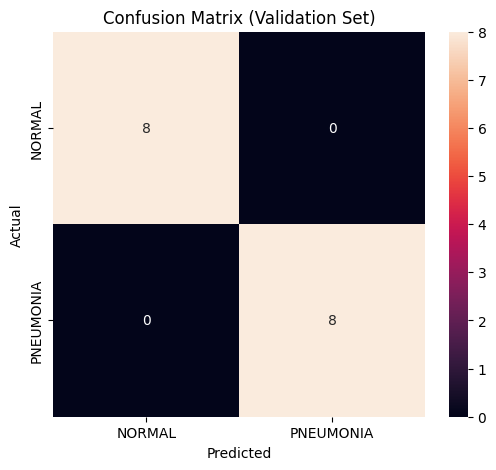

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Predict on test set
y_pred_prob_test = model.predict(val)
y_pred_test = (y_pred_prob_test > 0.5).astype(int)  # binary threshold 0.5

# Step 2: True labels
y_true_test = val.classes

# Step 3: Confusion Matrix
cm_test = confusion_matrix(y_true_test, y_pred_test)


# Step 4: Classification Report
cr_test = classification_report(y_true_test, y_pred_test, target_names=list(val.class_indices.keys()))
print("\nClassification Report (Test Set):\n", cr_test)

# Step 5: Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=list(val.class_indices.keys()),
            yticklabels=list(val.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 397ms/step

Classification Report (Test Set):
               precision    recall  f1-score   support

      NORMAL       0.35      0.32      0.34       234
   PNEUMONIA       0.61      0.64      0.62       390

    accuracy                           0.52       624
   macro avg       0.48      0.48      0.48       624
weighted avg       0.51      0.52      0.52       624



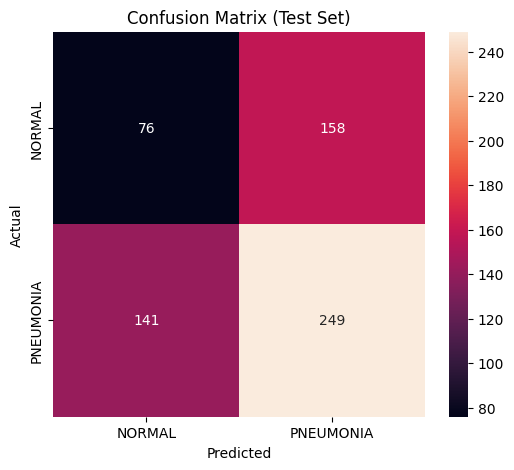

In [ ]:
# Step 1: Predict on test set
y_pred_prob_test = model.predict(test)
y_pred_test=(y_pred_prob_test>0.5).astype(int)

# Step 2: True labels
y_true_test=test.classes

# Step 4: Classification Report
cr_test = classification_report(y_true_test, y_pred_test, target_names=list(test.class_indices.keys()))
print("\nClassification Report (Test Set):\n", cr_test)

# Step 5: Plot Confusion Matrix
cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=list(val.class_indices.keys()),
            yticklabels=list(val.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 446ms/step


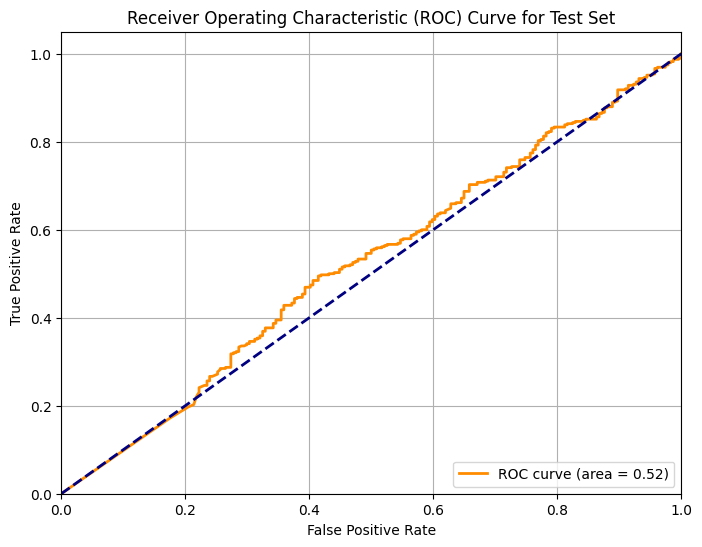

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming y_true_test and y_pred_prob_test are already available from previous cells
# If not, you might need to re-run the prediction on the test set:
y_pred_prob_test = model.predict(test)
y_true_test = test.classes

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true_test, y_pred_prob_test)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()